In [21]:
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

In [23]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [24]:
df.shape

(374, 13)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [26]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [27]:
df.isnull().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


In [28]:
df.rename(columns={
    "Person ID": "Person_ID",
    "Sleep Duration": "Sleep_Duration",
    "Quality of Sleep": "Quality_of_Sleep",
    "Physical Activity Level": "Physical_Activity_Level",
    "Stress Level": "Stress_Level",
    "BMI Category": "BMI_Category",
    "Blood Pressure": "Blood_Pressure",
    "Heart Rate": "Heart_Rate",
    "Daily Steps": "Daily_Steps",
    "Sleep Disorder": "Sleep_Disorder"
}, inplace=True)

In [29]:
df.drop("Person_ID", axis=1, inplace=True)

In [30]:
df[["Systolic_BP", "Diastolic_BP"]] = df["Blood_Pressure"].str.split("/", expand=True)

df["Systolic_BP"] = df["Systolic_BP"].astype(int)
df["Diastolic_BP"] = df["Diastolic_BP"].astype(int)

df.drop("Blood_Pressure", axis=1, inplace=True)

In [31]:
df.isnull().sum()

,0
Gender,0
Age,0
Occupation,0
Sleep_Duration,0
Quality_of_Sleep,0
Physical_Activity_Level,0
Stress_Level,0
BMI_Category,0
Heart_Rate,0
Daily_Steps,0


In [32]:
df["Sleep_Disorder"].unique()

array([nan, 'Sleep Apnea', 'Insomnia'], dtype=object)

In [33]:
df["Sleep_Disorder"].value_counts(dropna=False)

,count
Sleep_Disorder,
NaN,219
Sleep Apnea,78
Insomnia,77


In [34]:
df["Sleep_Disorder"] = df["Sleep_Disorder"].fillna("None")

In [35]:
df.isnull().sum()

,0
Gender,0
Age,0
Occupation,0
Sleep_Duration,0
Quality_of_Sleep,0
Physical_Activity_Level,0
Stress_Level,0
BMI_Category,0
Heart_Rate,0
Daily_Steps,0


In [36]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    "Gender",
    "Occupation",
    "BMI_Category",
    "Sleep_Disorder"
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    int64  
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    int64  
 3   Sleep_Duration           374 non-null    float64
 4   Quality_of_Sleep         374 non-null    int64  
 5   Physical_Activity_Level  374 non-null    int64  
 6   Stress_Level             374 non-null    int64  
 7   BMI_Category             374 non-null    int64  
 8   Heart_Rate               374 non-null    int64  
 9   Daily_Steps              374 non-null    int64  
 10  Sleep_Disorder           374 non-null    int64  
 11  Systolic_BP              374 non-null    int64  
 12  Diastolic_BP             374 non-null    int64  
dtypes: float64(1), int64(12)
memory usage: 38.1 KB


In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [39]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

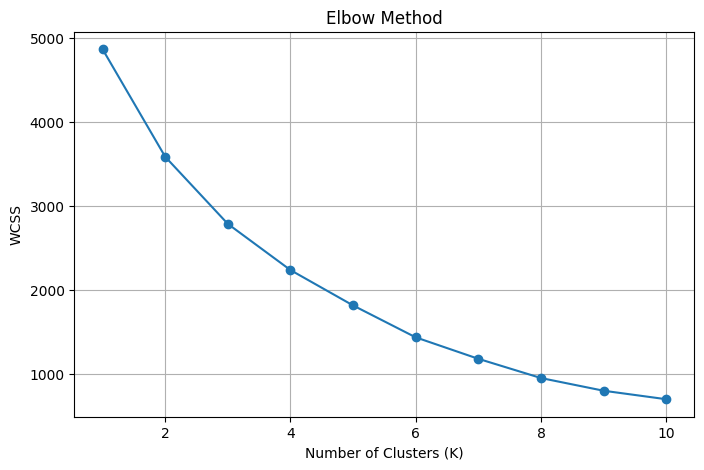

In [40]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [41]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

In [42]:
df["Cluster"].value_counts()

,count
Cluster,
1,178
0,102
2,94


In [43]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [44]:
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

pca_df["Cluster"] = clusters

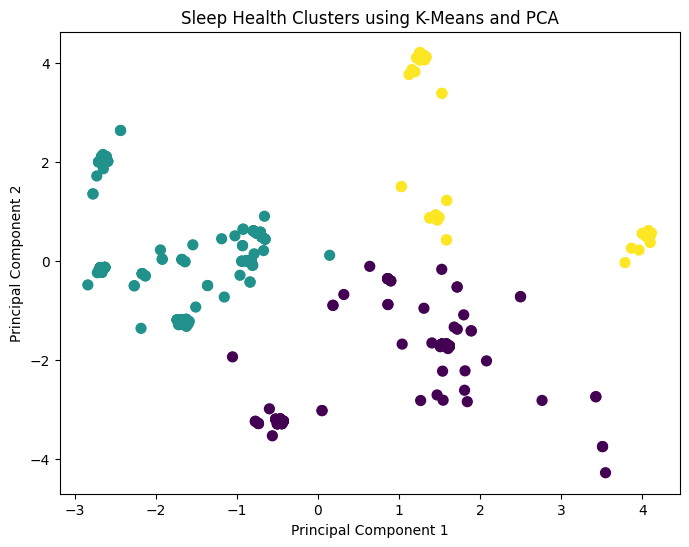

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    s=50
)

plt.title("Sleep Health Clusters using K-Means and PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [46]:
cluster_summary = df.groupby("Cluster").mean()

cluster_summary

,Gender,Age,Occupation,Sleep_Duration,Quality_of_Sleep,Physical_Activity_Level,Stress_Level,BMI_Category,Heart_Rate,Daily_Steps,Sleep_Disorder,Systolic_BP,Diastolic_BP
Cluster,,,,,,,,,,,,,
0,0.803922,37.833333,4.323529,6.354902,6.000000,40.441176,7.166667,1.833333,73.784314,5516.666667,0.686275,128.421569,83.617647
1,0.589888,39.971910,2.095506,7.661236,8.016854,63.455056,4.539326,0.101124,68.185393,7137.078652,0.988764,123.353933,80.578652
2,0.021277,51.095745,6.351064,6.973404,7.404255,71.382979,5.053191,2.978723,69.989362,7621.276596,1.372340,138.542553,93.478723


In [47]:
cluster_summary = df.groupby("Cluster").mean().round(2)
cluster_summary

,Gender,Age,Occupation,Sleep_Duration,Quality_of_Sleep,Physical_Activity_Level,Stress_Level,BMI_Category,Heart_Rate,Daily_Steps,Sleep_Disorder,Systolic_BP,Diastolic_BP
Cluster,,,,,,,,,,,,,
0,0.80,37.83,4.32,6.35,6.00,40.44,7.17,1.83,73.78,5516.67,0.69,128.42,83.62
1,0.59,39.97,2.10,7.66,8.02,63.46,4.54,0.10,68.19,7137.08,0.99,123.35,80.58
2,0.02,51.10,6.35,6.97,7.40,71.38,5.05,2.98,69.99,7621.28,1.37,138.54,93.48
